In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
file_path = Path("../data/swan_visit_3.tsv")

df_v3 = pd.read_csv(file_path, sep="\t", low_memory=False)

print(df_v3.shape)
print(df_v3.columns[df_v3.columns.str.contains("TYPNIGH|SLEEPQL", case=False, regex=True)])

(2709, 627)
Index(['TYPNIGH3', 'SLEEPQL3'], dtype='object')


In [ ]:
sleep_v3 = df_v3[["SWANID", "TYPNIGH3", "SLEEPQL3"]].copy()

# Replace missing codes with NaN
missing_codes = [-9, "-9", -8, "-8", -7, "-7", -1, "-1", ".", " "]
sleep_v3 = sleep_v3.replace(missing_codes, np.nan)

# Convert to numeric
sleep_v3["TYPNIGH3"] = pd.to_numeric(sleep_v3["TYPNIGH3"], errors="coerce")
sleep_v3["SLEEPQL3"] = pd.to_numeric(sleep_v3["SLEEPQL3"], errors="coerce")

# Keep complete cases for comparison
sleep_complete = sleep_v3.dropna(subset=["TYPNIGH3", "SLEEPQL3"])

print(sleep_complete.shape)
print(sleep_complete[["TYPNIGH3", "SLEEPQL3"]].describe())

(2615, 3)
          TYPNIGH3     SLEEPQL3
count  2615.000000  2615.000000
mean      2.766730     1.957553
std       1.345699     1.119195
min      -9.000000    -9.000000
25%       2.000000     2.000000
50%       3.000000     2.000000
75%       3.000000     2.000000
max       5.000000     4.000000


In [6]:
sleep_complete = sleep_complete[
    (sleep_complete["TYPNIGH3"].between(1,5)) &
    (sleep_complete["SLEEPQL3"].between(1,4))
].copy()

In [7]:
print("TYPNIGH3 distribution:")
print(sleep_complete["TYPNIGH3"].value_counts(dropna=False).sort_index())

print("SLEEPQL3 distribution:")
print(sleep_complete["SLEEPQL3"].value_counts(dropna=False).sort_index())

TYPNIGH3 distribution:
TYPNIGH3
1.0     223
2.0     649
3.0    1124
4.0     493
5.0      97
Name: count, dtype: int64
SLEEPQL3 distribution:
SLEEPQL3
1.0     575
2.0    1462
3.0     453
4.0      96
Name: count, dtype: int64


In [8]:
crosstab_counts = pd.crosstab(
    sleep_complete["TYPNIGH3"],
    sleep_complete["SLEEPQL3"]
)

crosstab_row_pct = pd.crosstab(
    sleep_complete["TYPNIGH3"],
    sleep_complete["SLEEPQL3"],
    normalize="index"
)

print("Counts:")
print(crosstab_counts)

print("Row percentages:")
print((crosstab_row_pct * 100).round(1))

Counts:
SLEEPQL3  1.0  2.0  3.0  4.0
TYPNIGH3                    
1.0       205   17    1    0
2.0       287  357    5    0
3.0        76  930  110    8
4.0         6  156  298   33
5.0         1    2   39   55
Row percentages:
SLEEPQL3   1.0   2.0   3.0   4.0
TYPNIGH3                        
1.0       91.9   7.6   0.4   0.0
2.0       44.2  55.0   0.8   0.0
3.0        6.8  82.7   9.8   0.7
4.0        1.2  31.6  60.4   6.7
5.0        1.0   2.1  40.2  56.7


In [9]:
spearman_corr = sleep_complete[["TYPNIGH3", "SLEEPQL3"]].corr(method="spearman")

print(spearman_corr)

          TYPNIGH3  SLEEPQL3
TYPNIGH3  1.000000  0.735704
SLEEPQL3  0.735704  1.000000


## Agreement-style analysis: mapping TYPNIGH to SLEEPQL scale

In [10]:
sleep_complete = sleep_complete[
    (sleep_complete["TYPNIGH3"].between(1,5)) &
    (sleep_complete["SLEEPQL3"].between(1,4))
].copy()

In [11]:
def typnigh_to_sleepql(x):
    if pd.isna(x):
        return np.nan
    if x == 1:
        return 1  # very good
    elif x in [2, 3]:
        return 2  # fairly good
    elif x == 4:
        return 3  # fairly bad
    elif x == 5:
        return 4  # very bad
    else:
        return np.nan

sleep_complete["TYPNIGH3_mapped"] = sleep_complete["TYPNIGH3"].apply(typnigh_to_sleepql)

mapped_crosstab = pd.crosstab(
    sleep_complete["TYPNIGH3_mapped"],
    sleep_complete["SLEEPQL3"],
    normalize="index"
)

print((mapped_crosstab * 100).round(1))

SLEEPQL3          1.0   2.0   3.0   4.0
TYPNIGH3_mapped                        
1                91.9   7.6   0.4   0.0
2                20.5  72.6   6.5   0.5
3                 1.2  31.6  60.4   6.7
4                 1.0   2.1  40.2  56.7


In [12]:
agreement = (sleep_complete["TYPNIGH3_mapped"] == sleep_complete["SLEEPQL3"]).mean()

print(f"Exact agreement after mapping: {agreement:.2%}")

Exact agreement after mapping: 71.35%


## Weighted Kappa

Cohen's weighted kappa accounts for ordinal structure — near-misses are penalised
less than large disagreements. Linear weights are standard for ordinal scales.
Interpretation benchmarks (Landis & Koch, 1977):
  0.00–0.20  Slight
  0.21–0.40  Fair
  0.41–0.60  Moderate
  0.61–0.80  Substantial
  0.81–1.00  Almost perfect

For comparison, Racine et al. (2025) reported weighted kappa values of 0.61 and 0.60
when harmonising self-rated health and self-rated memory across different Likert formats,
describing these as reflecting 'moderate agreement' and treating them as sufficient
to support harmonisation.

In [13]:
# Drop any rows where mapping produced NaN
kappa_df = sleep_complete.dropna(subset=["TYPNIGH3_mapped", "SLEEPQL3"]).copy()

# Convert to int for cohen_kappa_score
y1 = kappa_df["TYPNIGH3_mapped"].astype(int).values
y2 = kappa_df["SLEEPQL3"].astype(int).values

# Linear weighted kappa — appropriate for ordinal scales
kappa_linear = cohen_kappa_score(y1, y2, weights="linear")

# Quadratic weighted kappa — penalises larger disagreements more heavily
kappa_quadratic = cohen_kappa_score(y1, y2, weights="quadratic")

# Unweighted kappa for reference
kappa_unweighted = cohen_kappa_score(y1, y2, weights=None)

print(f"Unweighted kappa:          {kappa_unweighted:.3f}")
print(f"Linear weighted kappa:     {kappa_linear:.3f}")
print(f"Quadratic weighted kappa:  {kappa_quadratic:.3f}")
print()
print("For ordinal harmonisation, linear weighted kappa is the primary metric.")
print("Values above 0.61 indicate substantial agreement (Landis & Koch, 1977).")

Unweighted kappa:          0.487
Linear weighted kappa:     0.571
Quadratic weighted kappa:  0.679

For ordinal harmonisation, linear weighted kappa is the primary metric.
Values above 0.61 indicate substantial agreement (Landis & Koch, 1977).


## Summary of harmonisation evidence

Taken together, the three metrics provide convergent evidence for the crosswalk quality:
- Spearman rho assesses monotonic rank correlation between raw scales
- Exact agreement assesses how often the mapping produces a perfect category match
- Weighted kappa accounts for ordinal structure and chance agreement

# Plots

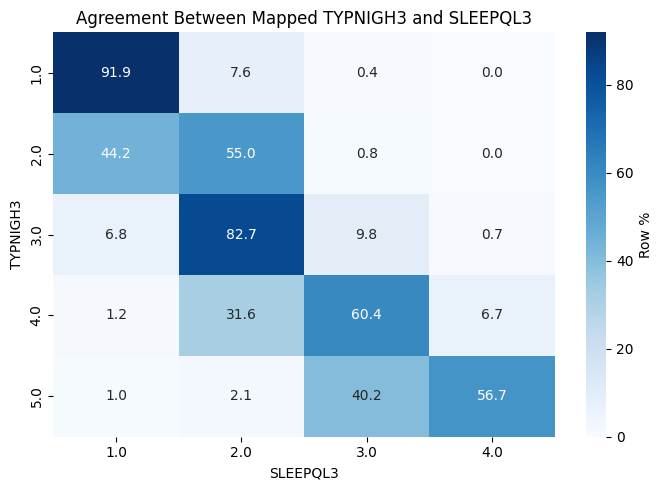

In [26]:
plt.figure(figsize=(7,5))

sns.heatmap(
    crosstab_row_pct * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Row %"}
)

plt.xlabel("SLEEPQL3")
plt.ylabel("TYPNIGH3")
plt.title("Agreement Between Mapped TYPNIGH3 and SLEEPQL3")

plt.tight_layout()
plt.show()